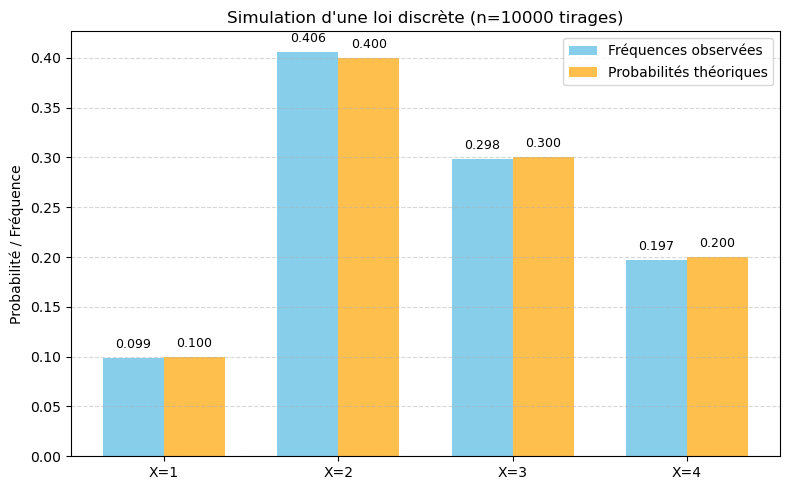

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 设定概率分布
p = [0.1, 0.4, 0.3, 0.2]          # p1, p2, p3, p4
valeurs = [1, 2, 3, 4]             # 对应的取值 x_k

# 计算累积概率区间边界 u_k
cumul = np.cumsum(p)               # [0.1, 0.5, 0.8, 1.0]
# 添加起点 0
bornes = np.concatenate(([0], cumul))

# 模拟次数
n_sim = 10000

# 生成均匀分布随机数
U = np.random.uniform(0, 1, n_sim)

# 方法：找到第一个累积概率 > U 的索引，然后 +1
# 注意：对于 U=0.0 到 0.1（不含）返回索引0，+1=1，正确
# 对于 U=0.1 到 0.5（不含）返回索引1，+1=2，正确
# 对于 U=0.5 到 0.8（不含）返回索引2，+1=3，正确
# 对于 U=0.8 到 1.0（含）返回索引3，+1=4，正确
indices = np.searchsorted(cumul, U, side='right')  # 返回 0..len(cumul)
X_sim = indices + 1   # 转换为 1..4

# 计算每个取值的频率
freq = [np.sum(X_sim == v) / n_sim for v in valeurs]

# 绘图
plt.figure(figsize=(8,5))
x = np.arange(len(valeurs))
width = 0.35

plt.bar(x - width/2, freq, width, label='Fréquences observées', color='skyblue')
plt.bar(x + width/2, p, width, label='Probabilités théoriques', color='orange', alpha=0.7)

plt.xticks(x, [f'X={v}' for v in valeurs])
plt.ylabel('Probabilité / Fréquence')
plt.title(f'Simulation d\'une loi discrète (n={n_sim} tirages)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 添加数值标签
for i, (f, th) in enumerate(zip(freq, p)):
    plt.text(i - width/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, th + 0.01, f'{th:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
n_sample = 100
U_sample = np.random.uniform(0, 1, n_sample)
indices_sample = np.searchsorted(cumul, U_sample, side='right')
X_sample = indices_sample + 1
print("\n10个服从该分布的随机数:", X_sample.tolist())


10个服从该分布的随机数: [2, 3, 4, 1, 3, 2, 2, 2, 3, 2, 3, 2, 1, 2, 2, 4, 2, 4, 4, 2, 4, 3, 4, 2, 3, 2, 3, 3, 3, 1, 3, 2, 2, 4, 2, 2, 2, 3, 2, 2, 4, 4, 3, 1, 3, 2, 2, 4, 4, 4, 2, 2, 2, 3, 4, 2, 1, 3, 3, 2, 2, 2, 4, 2, 4, 2, 2, 3, 2, 4, 2, 2, 2, 2, 2, 3, 3, 4, 2, 3, 4, 3, 4, 2, 2, 4, 2, 2, 2, 2, 3, 3, 4, 3, 1, 2, 2, 1, 1, 3]


Loi de Geometrique avec $p=1/3$

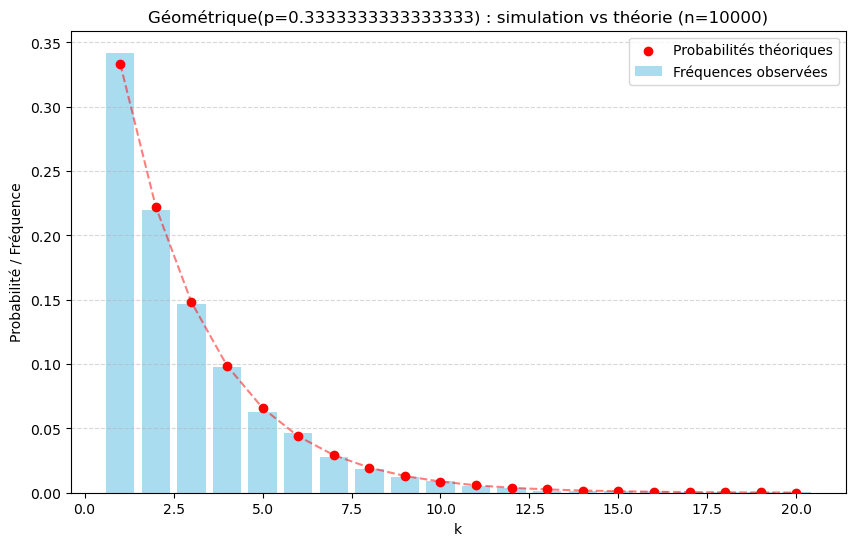

k	Théorique	Observé
1	0.3333		0.3420
2	0.2222		0.2199
3	0.1481		0.1467
4	0.0988		0.0978
5	0.0658		0.0626
6	0.0439		0.0465
7	0.0293		0.0278
8	0.0195		0.0186
9	0.0130		0.0125
10	0.0087		0.0091
11	0.0058		0.0054
12	0.0039		0.0039
13	0.0026		0.0012
14	0.0017		0.0016
15	0.0011		0.0016
16	0.0008		0.0010
17	0.0005		0.0004
18	0.0003		0.0006
19	0.0002		0.0002
20	0.0002		0.0003


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 参数
p = 1/3
n_sim = 10000

# 逆变换法生成几何分布随机数
U = np.random.uniform(0, 1, n_sim)
X = 1 + np.floor(np.log(1 - U) / np.log(1 - p)).astype(int)

# 计算理论概率（前10个值用于对比）
k_vals = np.arange(1, 21)  # 展示1到20
theoretical_probs = p * (1 - p) ** (k_vals - 1)

# 计算模拟频率
unique, counts = np.unique(X, return_counts=True)
freq = counts / n_sim

# 绘图对比（限于1到20）
plt.figure(figsize=(10,6))
plt.bar(unique[:20], freq[:20], alpha=0.7, label='Fréquences observées', color='skyblue')
plt.scatter(k_vals, theoretical_probs, color='red', zorder=3, label='Probabilités théoriques')
plt.plot(k_vals, theoretical_probs, 'r--', alpha=0.5)
plt.xlabel('k')
plt.ylabel('Probabilité / Fréquence')
plt.title(f'Géométrique(p={p}) : simulation vs théorie (n={n_sim})')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 输出前20个理论概率和模拟频率对比
print("k\tThéorique\tObservé")
for k in range(1, 21):
    theo = theoretical_probs[k-1]
    obs = freq[k-1] if k <= len(freq) else 0
    print(f"{k}\t{theo:.4f}\t\t{obs:.4f}")

Loi exponentielle $X\sim\mathcal{E}(\lambda)$

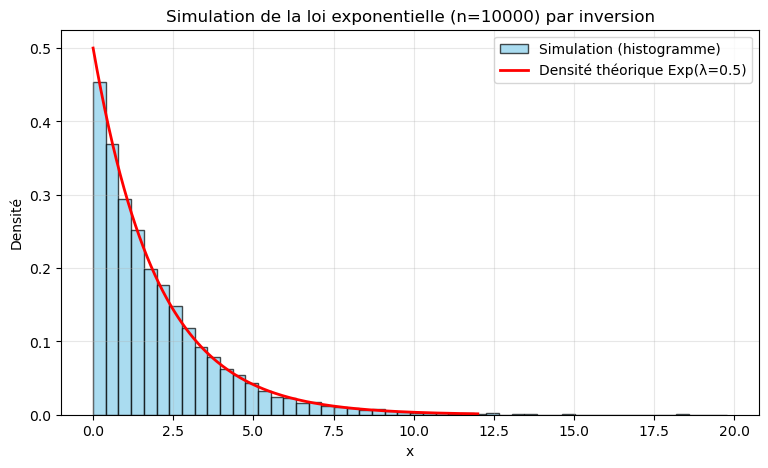

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
lambd = 0.5   # 指数分布的速率参数 λ
n = 10000     # 样本数量

# 逆变换法生成指数分布随机数
U = np.random.uniform(0, 1, n)
X = -np.log(1 - U) / lambd   # 或使用 -np.log(U)/lambd

# 理论密度函数
x_vals = np.linspace(0, 12, 200)
pdf_theory = lambd * np.exp(-lambd * x_vals)

# 绘图
plt.figure(figsize=(9,5))
plt.hist(X, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Simulation (histogramme)')
plt.plot(x_vals, pdf_theory, 'r-', linewidth=2, label=f'Densité théorique Exp(λ={lambd})')
plt.xlabel('x')
plt.ylabel('Densité')
plt.title(f'Simulation de la loi exponentielle (n={n}) par inversion')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Loi uniforme sur un disque

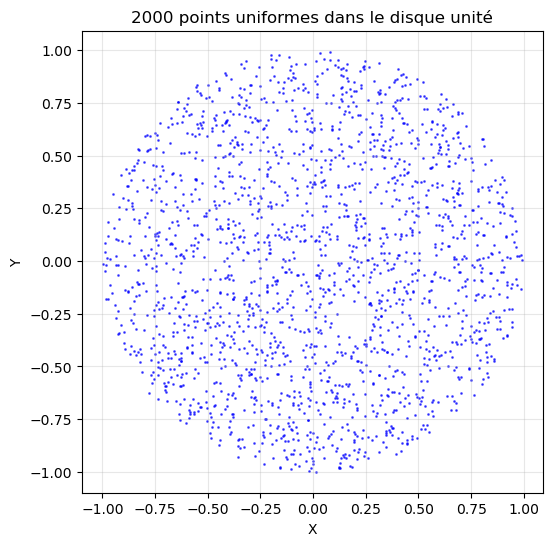

In [10]:


# 参数设置
n = 2000  # 点的数量

# 生成独立的 R^2 ~ U(0,1) 和 Theta ~ U(0, 2π)
U = np.random.uniform(0, 1, n)          # R^2
Theta = np.random.uniform(0, 2*np.pi, n)

# 计算半径和坐标
R = np.sqrt(U)                          # 因为 R = sqrt(R^2)
X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# 绘图
plt.figure(figsize=(6,6))
plt.scatter(X, Y, s=1, alpha=0.6, color='blue')
plt.gca().set_aspect('equal')
plt.title(f'{n} points uniformes dans le disque unité')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(alpha=0.3)
plt.show()